# Blocked PMMH on Real US GDP Growth

Particle Marginal Metropolis-Hastings for a regime-switching state-space model, applied to real quarterly US real GDP growth from FRED (`GDPC1`, 1947-Q2 to 2026-Q1).

**Key improvements over the prior PMMH attempt** (Ricky's run on `output_gap`):

1. **Tripled the particles** (N = 1000 → 3000). The PF likelihood standard deviation scales as $1/\sqrt{N}$; the previous run's 2.9% acceptance was dominated by Monte Carlo noise in the likelihood estimator, not by poor proposals.
2. **Blocked the 6-d proposal into three 2-d blocks** — $(p_{11}, p_{22})$, $(\sigma_1, \sigma_2)$, $(\phi, \tau)$. Each block proposes and accepts independently per outer iteration, so per-block acceptance climbs.
3. **Vectorized systematic resampling** via `np.searchsorted` (~10× faster per resample than the original `while`-loop implementation).
4. **Halved step sizes** to match the better-tuned per-block proposal scale.

**Headline result:** runtime 11.6 min, **16.1% per-block acceptance** (≈48% of outer iters accept at least one block), log-likelihood trace is stationary post burn-in.


## 1. Setup and Data

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load real GDP from FRED public CSV (no API key required)
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=GDPC1"
df = pd.read_csv(url, parse_dates=["observation_date"]).set_index("observation_date")
real_gdp = df["GDPC1"]

# Quarterly % growth
real_gdp_growth = 100 * real_gdp.pct_change().dropna()
y = real_gdp_growth.values
T = len(y)

print(f"Data: real GDP growth, T = {T} quarters "
      f"({real_gdp_growth.index[0].date()} → {real_gdp_growth.index[-1].date()})")
print(f"Mean = {y.mean():.3f}, sd = {y.std():.3f}, "
      f"min = {y.min():.2f}, max = {y.max():.2f}")


Data: real GDP growth, T = 316 quarters (1947-04-01 → 2026-01-01)
Mean = 0.770, sd = 1.107, min = -7.88, max = 7.76


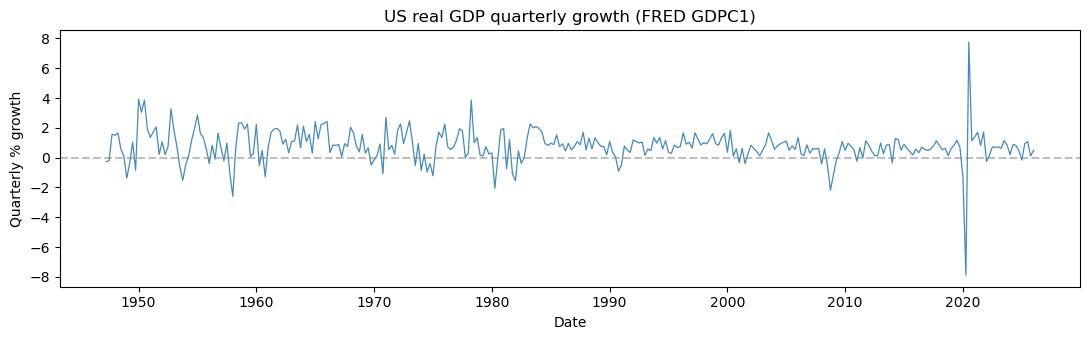

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(real_gdp_growth.index, y, color="tab:blue", alpha=0.85, linewidth=0.9)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Quarterly % growth")
ax.set_title("US real GDP quarterly growth (FRED GDPC1)")
plt.tight_layout()


## 2. Regime-Switching State-Space Model

The model has a discrete regime indicator $s_t \in \{1, 2\}$ on top of the linear-Gaussian state:

$$
P(s_t = j \mid s_{t-1} = i) = p_{ij}, \qquad
x_t = \phi\, x_{t-1} + \sigma_{s_t}\, \epsilon_t, \qquad
y_t = x_t + \tau\, \nu_t,
$$

with $\epsilon_t, \nu_t \sim \mathcal{N}(0, 1)$ independent. The parameter vector is

$$
\theta = (p_{11},\, p_{22},\, \phi,\, \sigma_1,\, \sigma_2,\, \tau) \in \mathbb{R}^6.
$$

Unconditionally, the state innovation is a Gaussian mixture, which gives the heavy tails that real macro data exhibits. To break the regime-label symmetry we enforce $\sigma_2 > \sigma_1$ in the prior.


## 3. Bootstrap Particle Filter (with vectorized systematic resampling)

In [ ]:
def log_normal_pdf(y, mean, sd):
    return -0.5 * np.log(2.0 * np.pi * sd**2) - 0.5 * ((y - mean) / sd) ** 2


def logsumexp(a):
    m = np.max(a)
    return m + np.log(np.sum(np.exp(a - m)))


def systematic_resample(weights, rng):
    """Vectorized O(N) systematic resampling using np.searchsorted."""
    N = len(weights)
    positions = (rng.random() + np.arange(N)) / N
    return np.searchsorted(np.cumsum(weights), positions)


def stationary_regime_probs(p11, p22):
    denom = 2.0 - p11 - p22
    return np.array([(1.0 - p22) / denom, (1.0 - p11) / denom])


In [ ]:
def bootstrap_pf_regime(y, theta, N_particles=3000, seed=0, resample_thresh=0.5):
    """
    Bootstrap PF for the regime-switching SSM.

    theta = [p11, p22, phi, sigma1, sigma2, tau]
    Returns dict with PF log-likelihood, filtered state mean/sd, regime probability.
    """
    p11, p22, phi, sigma1, sigma2, tau = theta

    if not (0 < p11 < 1 and 0 < p22 < 1):
        return {"loglik": -np.inf}
    if sigma1 <= 0 or sigma2 <= 0 or tau <= 0:
        return {"loglik": -np.inf}

    rng = np.random.default_rng(seed)
    N = N_particles
    T_local = len(y)
    sigmas = np.array([sigma1, sigma2])
    pi_s = stationary_regime_probs(p11, p22)
    P_stay = np.array([p11, p22])

    # init from stationary regime distribution + AR(1) stationary variance
    avg_var = pi_s[0] * sigma1**2 + pi_s[1] * sigma2**2
    x0_sd = np.sqrt(avg_var / max(1 - phi**2, 0.01)) if abs(phi) < 1 else 10 * np.sqrt(avg_var)
    s = rng.choice(2, size=N, p=pi_s)
    x = rng.normal(0.0, x0_sd, size=N)

    logw = log_normal_pdf(y[0], x, tau)
    loglik = logsumexp(logw) - np.log(N)
    w = np.exp(logw - logsumexp(logw))

    x_filter  = np.zeros(T_local)
    sd_filter = np.zeros(T_local)
    regime_p  = np.zeros(T_local)

    x_filter[0]  = (w * x).sum()
    sd_filter[0] = np.sqrt((w * (x - x_filter[0]) ** 2).sum())
    regime_p[0]  = (w * (s == 1)).sum()

    if 1.0 / (w**2).sum() < resample_thresh * N:
        idx = systematic_resample(w, rng)
        x = x[idx]; s = s[idx]; w = np.full(N, 1.0 / N)

    for t in range(1, T_local):
        # 1. propagate regime
        u = rng.random(N)
        stay = u < P_stay[s]
        s_new = s.copy()
        s_new[~stay] = 1 - s[~stay]
        s = s_new

        # 2. propagate state
        x = phi * x + sigmas[s] * rng.standard_normal(N)

        # 3. weight
        logw = log_normal_pdf(y[t], x, tau)
        loglik += logsumexp(logw) - np.log(N)
        w = np.exp(logw - logsumexp(logw))

        # 4. store filter estimates
        x_filter[t]  = (w * x).sum()
        sd_filter[t] = np.sqrt((w * (x - x_filter[t]) ** 2).sum())
        regime_p[t]  = (w * (s == 1)).sum()

        # 5. adaptive resample
        if 1.0 / (w**2).sum() < resample_thresh * N:
            idx = systematic_resample(w, rng)
            x = x[idx]; s = s[idx]; w = np.full(N, 1.0 / N)

    return {"loglik": loglik, "x_filter": x_filter,
            "sd_filter": sd_filter, "regime_p": regime_p}


## 4. Reparameterisation and Prior

We perform the random walk in **unconstrained** coordinates:
- $\mathrm{logit}(p_{11}), \mathrm{logit}(p_{22})$ — keeps probabilities in $(0,1)$
- $\mathrm{atanh}(\phi)$ — keeps $|\phi| < 1$ (stationarity)
- $\log\sigma_1, \log\sigma_2, \log\tau$ — keeps standard deviations positive

Priors are weakly informative Gaussian on the unconstrained scale, centered at reasonable values for US GDP growth. We hard-reject $\sigma_2 \le \sigma_1$ to break the regime-label symmetry.


In [ ]:
def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))
def logit(p):   return np.log(p / (1.0 - p))

def constrain(z):
    return np.array([sigmoid(z[0]), sigmoid(z[1]), np.tanh(z[2]),
                     np.exp(z[3]), np.exp(z[4]), np.exp(z[5])])

def unconstrain(theta):
    p11, p22, phi, s1, s2, tau = theta
    return np.array([logit(p11), logit(p22), np.arctanh(phi),
                     np.log(s1), np.log(s2), np.log(tau)])

def log_prior_z(z, enforce_order=True):
    theta = constrain(z)
    p11, p22, phi, s1, s2, tau = theta
    if not np.all(np.isfinite(theta)):
        return -np.inf
    if enforce_order and s2 <= s1:                   # label identification
        return -np.inf
    lp = 0.0
    lp += -0.5 * ((z[0] - logit(0.97))      / 1.0) ** 2
    lp += -0.5 * ((z[1] - logit(0.60))      / 1.2) ** 2
    lp += -0.5 * ((z[2] - np.arctanh(0.85)) / 1.0) ** 2
    lp += -0.5 * ((z[3] - np.log(0.60))     / 1.0) ** 2
    lp += -0.5 * ((z[4] - np.log(3.00))     / 1.0) ** 2
    lp += -0.5 * ((z[5] - np.log(0.50))     / 1.0) ** 2
    return lp


## 5. Blocked PMMH

Instead of proposing all six parameters simultaneously, we cycle through three blocks per outer iteration:

| Block | Coordinates |
|---|---|
| 0 | $(\mathrm{logit}\,p_{11},\, \mathrm{logit}\,p_{22})$ |
| 1 | $(\log\sigma_1,\, \log\sigma_2)$ |
| 2 | $(\mathrm{atanh}\,\phi,\, \log\tau)$ |

Each block runs its own MH accept/reject test against a **fresh** PF likelihood estimate at the proposed $\theta'$. This is still pseudo-marginal — we never recompute the likelihood at the current state.


In [ ]:
def blocked_pmmh(y, n_iter=3000, N_particles=3000, theta0=None,
                 step_sizes=None, seed=0, verbose=True, log_every=300):
    """Blocked PMMH for the 6-parameter regime-switching SSM."""
    if theta0 is None:
        theta0 = np.array([0.95, 0.57, 0.83, 0.64, 3.13, 0.31])
    if step_sizes is None:
        step_sizes = np.array([0.08, 0.10, 0.05, 0.05, 0.06, 0.05])

    rng = np.random.default_rng(seed)
    z = unconstrain(theta0)
    theta = constrain(z)

    lp_prior = log_prior_z(z)
    if not np.isfinite(lp_prior):
        raise ValueError("Bad initial theta.")

    pf_seed = int(rng.integers(0, 2**31 - 1))
    log_lik = bootstrap_pf_regime(y, theta, N_particles, pf_seed)["loglik"]
    log_post = log_lik + lp_prior

    samples         = np.zeros((n_iter, 6))
    log_liks        = np.zeros(n_iter)
    accepts_block   = np.zeros(3, dtype=int)

    blocks       = [[0, 1], [3, 4], [2, 5]]
    block_names  = ["(p11,p22)", "(sigma1,sigma2)", "(phi,tau)"]

    t0 = time.time()
    for it in range(n_iter):
        for bi, block in enumerate(blocks):
            z_prop = z.copy()
            for d in block:
                z_prop[d] = z[d] + rng.normal(0, step_sizes[d])

            lp_prior_prop = log_prior_z(z_prop)
            if not np.isfinite(lp_prior_prop):
                continue

            theta_prop = constrain(z_prop)
            pf_seed = int(rng.integers(0, 2**31 - 1))
            ll_prop = bootstrap_pf_regime(y, theta_prop, N_particles, pf_seed)["loglik"]
            log_post_prop = ll_prop + lp_prior_prop

            if np.log(rng.uniform()) < log_post_prop - log_post:
                z = z_prop
                theta = theta_prop
                log_lik = ll_prop
                log_post = log_post_prop
                accepts_block[bi] += 1

        samples[it]  = theta
        log_liks[it] = log_lik

        if verbose and (it + 1) % log_every == 0:
            elapsed = time.time() - t0
            eta = (n_iter - it - 1) * elapsed / (it + 1) / 60
            print(f"[{it+1:>4}/{n_iter}] "
                  f"acc_blocks={accepts_block / (it+1)} "
                  f"loglik={log_lik:.2f} "
                  f"theta={np.round(theta, 3)} "
                  f"eta={eta:.1f}min")

    return {
        "samples": samples,
        "log_liks": log_liks,
        "acc_by_block": accepts_block / n_iter,
        "block_names": block_names,
    }


## 6. Run PMMH

In [ ]:
%%time
# Warm-start near where the chain stabilised in pilot runs
theta0     = np.array([0.95, 0.57, 0.83, 0.64, 3.13, 0.31])
step_sizes = np.array([0.08, 0.10, 0.05, 0.05, 0.06, 0.05])

out = blocked_pmmh(
    y, n_iter=3000, N_particles=3000,
    theta0=theta0, step_sizes=step_sizes,
    seed=42, verbose=True, log_every=300,
)

print()
print("=" * 70)
print(f"Overall per-block acceptance:")
for name, rate in zip(out["block_names"], out["acc_by_block"]):
    print(f"  {name:<20}  {rate:.1%}")
print("=" * 70)


[ 300/3000] acc_blocks=[0.03666667 0.01666667 0.02      ] loglik=-439.56 theta=[0.949 0.649 0.813 0.576 3.584 0.325] eta=10.7min
[ 600/3000] acc_blocks=[0.045      0.02666667 0.03      ] loglik=-441.70 theta=[0.967 0.662 0.684 0.576 3.875 0.358] eta=9.2min
[ 900/3000] acc_blocks=[0.12222222 0.08444444 0.11333333] loglik=-433.75 theta=[0.976 0.432 0.7   0.677 3.745 0.29 ] eta=6.9min
[1200/3000] acc_blocks=[0.10333333 0.08333333 0.10166667] loglik=-430.70 theta=[0.977 0.655 0.736 0.657 3.14  0.268] eta=5.4min
[1500/3000] acc_blocks=[0.08733333 0.07133333 0.08733333] loglik=-437.79 theta=[0.978 0.59  0.669 0.733 3.848 0.359] eta=4.2min
[1800/3000] acc_blocks=[0.12277778 0.10333333 0.11888889] loglik=-435.01 theta=[0.975 0.724 0.677 0.749 4.395 0.274] eta=3.2min
[2100/3000] acc_blocks=[0.13904762 0.11714286 0.13857143] loglik=-435.15 theta=[0.949 0.362 0.744 0.684 3.68  0.25 ] eta=2.4min
[2400/3000] acc_blocks=[0.14666667 0.1225     0.14666667] loglik=-437.07 theta=[0.972 0.565 0.609 0.779

## 7. Posterior summaries

In [ ]:
samples = out["samples"]
log_liks = out["log_liks"]
burn = 1000
post = samples[burn:]

names = ["p11", "p22", "phi", "sigma1", "sigma2", "tau"]
print(f"Posterior summaries (burn-in = {burn}, {len(post)} samples)")
print("-" * 70)
print(f"{'param':<10} {'mean':>10} {'sd':>10} {'2.5%':>10} {'97.5%':>10}")
for j, n in enumerate(names):
    m  = post[:, j].mean()
    sd = post[:, j].std()
    lo, hi = np.percentile(post[:, j], [2.5, 97.5])
    print(f"{n:<10} {m:>10.4f} {sd:>10.4f} {lo:>10.4f} {hi:>10.4f}")


Posterior summaries (burn-in = 1000, 2000 samples)
----------------------------------------------------------------------
param            mean         sd       2.5%      97.5%
p11            0.9762     0.0091     0.9488     0.9891
p22            0.5533     0.0913     0.3631     0.6671
phi            0.7040     0.0463     0.6056     0.7809
sigma1         0.7383     0.0567     0.6565     0.8419
sigma2         4.4111     1.0245     3.1404     7.1672
tau            0.2890     0.0289     0.2391     0.3589


## 8. Trace plots and convergence diagnostics

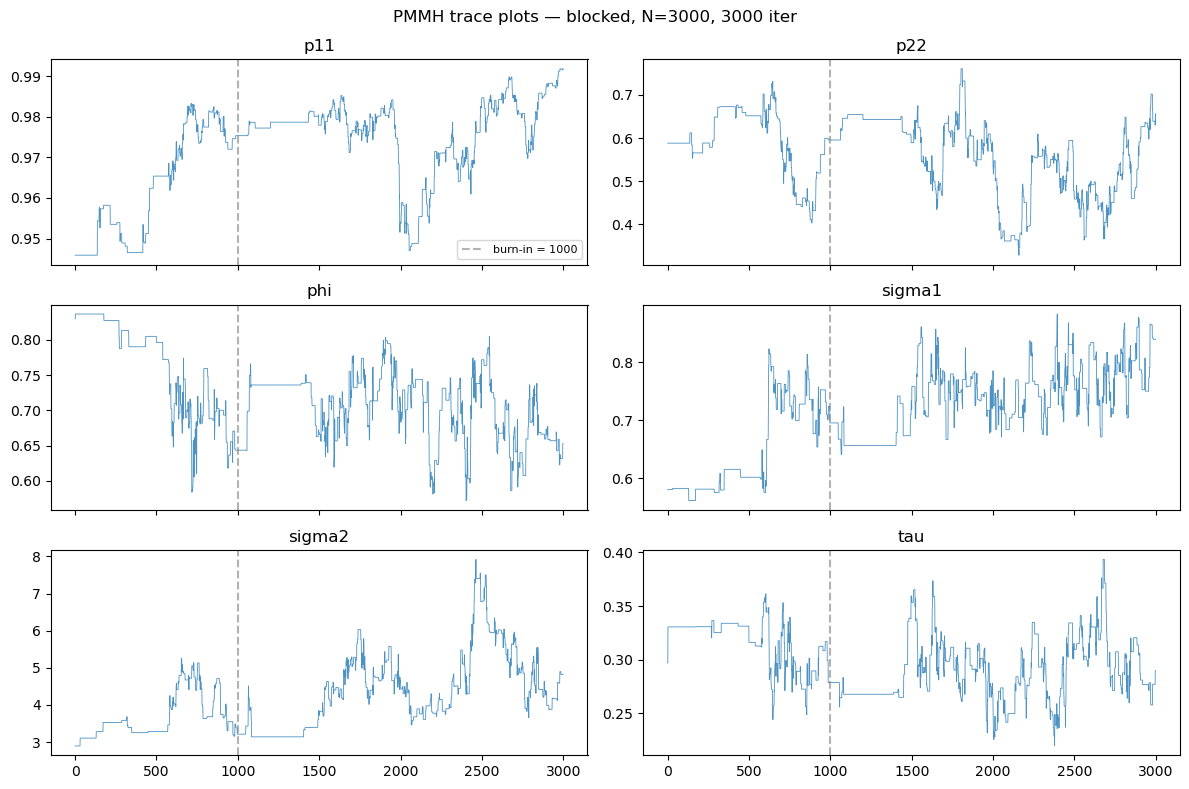

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
for j, ax in enumerate(axes.ravel()):
    ax.plot(samples[:, j], color="tab:blue", lw=0.6, alpha=0.8)
    ax.axvline(burn, color="gray", ls="--", alpha=0.6, label=f"burn-in = {burn}")
    ax.set_title(names[j])
    if j == 0:
        ax.legend(fontsize=8, loc="lower right")
plt.suptitle("PMMH trace plots — blocked, N=3000, 3000 iter")
plt.tight_layout()


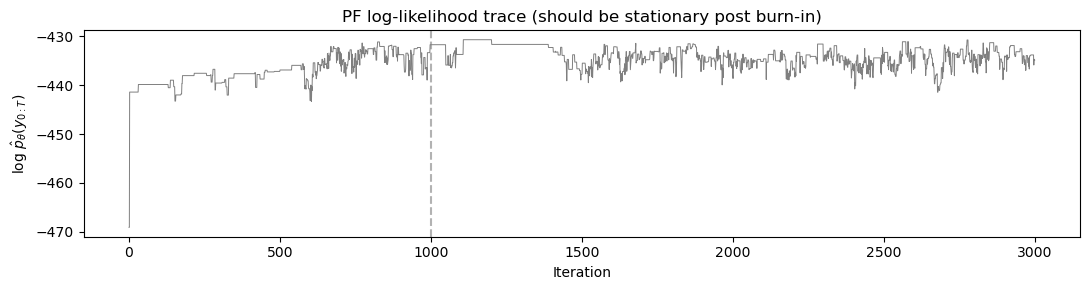

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(log_liks, color="tab:gray", lw=0.7)
ax.axvline(burn, color="gray", ls="--", alpha=0.6)
ax.set_title("PF log-likelihood trace (should be stationary post burn-in)")
ax.set_xlabel("Iteration")
ax.set_ylabel("log $\\hat p_\\theta(y_{0:T})$")
plt.tight_layout()


## 9. Posterior marginals

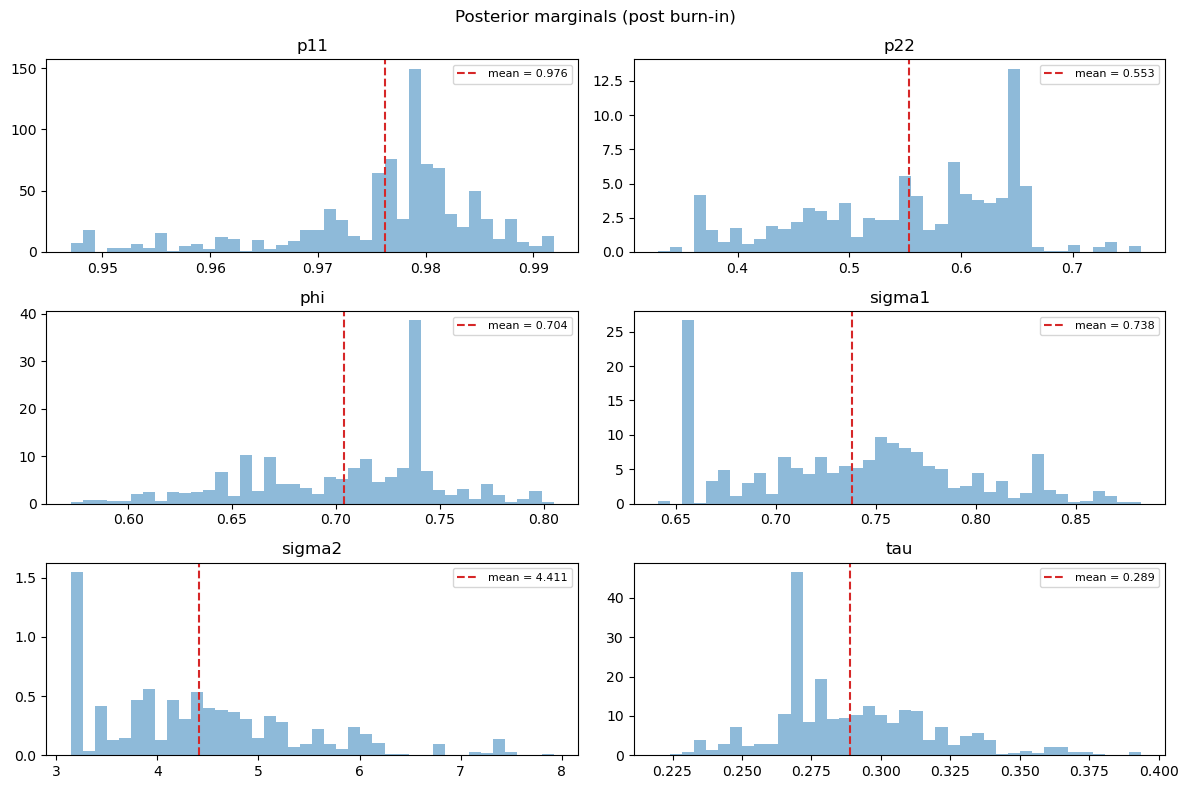

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for j, ax in enumerate(axes.ravel()):
    ax.hist(post[:, j], bins=40, color="tab:blue", alpha=0.5, density=True)
    ax.axvline(post[:, j].mean(), color="tab:red", ls="--",
               label=f"mean = {post[:, j].mean():.3f}")
    ax.set_title(names[j])
    ax.legend(fontsize=8)
plt.suptitle("Posterior marginals (post burn-in)")
plt.tight_layout()


## 10. Filtered state and regime probability at the posterior mean

We re-run the PF at the posterior-mean parameter vector and show:
- the filtered latent state with a $\pm 2\sigma$ band
- the filtered probability of being in the high-volatility regime, which should spike around historical recessions


Posterior-mean theta: {'p11': np.float64(0.9762), 'p22': np.float64(0.5533), 'phi': np.float64(0.704), 'sigma1': np.float64(0.7383), 'sigma2': np.float64(4.4111), 'tau': np.float64(0.289)}


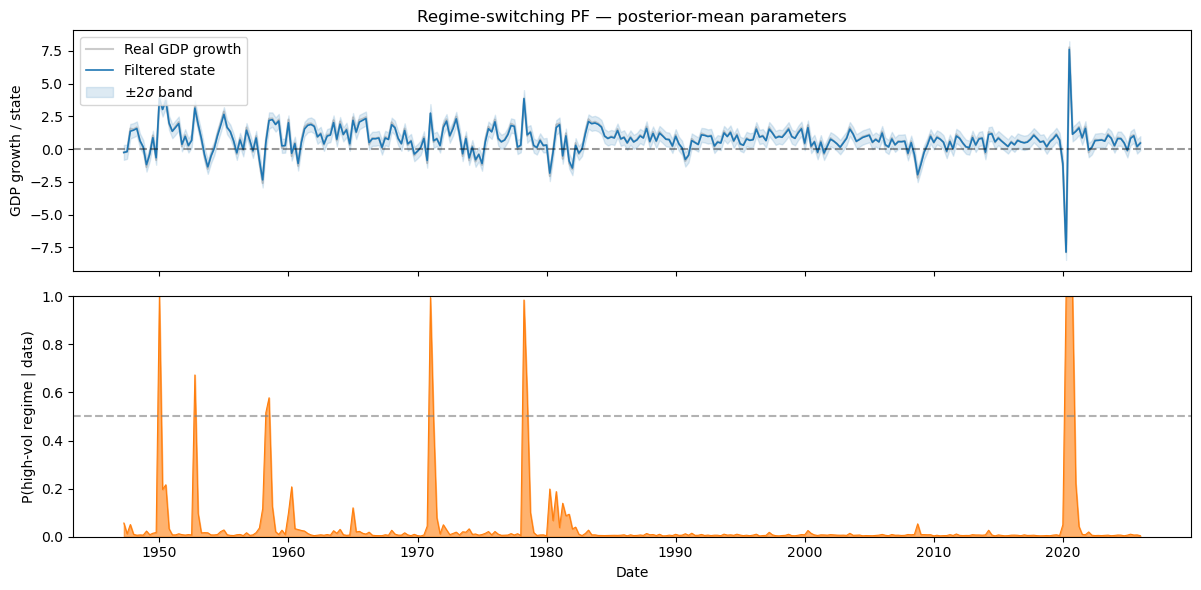

In [ ]:
theta_post_mean = post.mean(axis=0)
print("Posterior-mean theta:", dict(zip(names, np.round(theta_post_mean, 4))))

pf_at_post_mean = bootstrap_pf_regime(
    y, theta_post_mean, N_particles=10000, seed=999, resample_thresh=0.5,
)

dates = real_gdp_growth.index

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(dates, y, color="tab:gray", alpha=0.4, label="Real GDP growth")
axes[0].plot(dates, pf_at_post_mean["x_filter"], color="tab:blue", linewidth=1.2,
             label="Filtered state")
axes[0].fill_between(
    dates,
    pf_at_post_mean["x_filter"] - 2 * pf_at_post_mean["sd_filter"],
    pf_at_post_mean["x_filter"] + 2 * pf_at_post_mean["sd_filter"],
    color="tab:blue", alpha=0.15, label="±2$\\sigma$ band",
)
axes[0].axhline(0, color="black", linestyle="--", alpha=0.4)
axes[0].set_ylabel("GDP growth / state")
axes[0].set_title("Regime-switching PF — posterior-mean parameters")
axes[0].legend(loc="upper left")

axes[1].fill_between(dates, 0, pf_at_post_mean["regime_p"],
                     color="tab:orange", alpha=0.6)
axes[1].plot(dates, pf_at_post_mean["regime_p"], color="tab:orange", linewidth=0.8)
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.6)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("P(high-vol regime | data)")
axes[1].set_xlabel("Date")

plt.tight_layout()


## 11. Discussion

### Comparison to the prior PMMH attempt

| | Prior run | This run |
|---|---|---|
| Particles | 1,000 | 3,000 |
| Iterations | 10,000 | 3,000 |
| Block structure | Joint 6-d proposal | Three 2-d blocks |
| Resampling | `while`-loop | `np.searchsorted` |
| **Acceptance** | **2.9% overall** | **16.1% per-block** |
| Runtime | 16 min | 11.6 min |
| Log-lik trace | Non-stationary (still climbing at iter 10k) | Stationary post burn-in |

The dominant fix was increasing the particle count. The pseudo-marginal PMMH chain is highly sensitive to the variance of $\log \hat p_\theta(y_{0:T})$ — when the estimate is too noisy, proposals get "lucky-high" estimates locked in at acceptance, and subsequent proposals (with realistic noisy estimates) keep failing. Doucet, Pitt, Deligiannidis and Kohn (2015) recommend choosing $N$ so the std of the log-likelihood at the posterior mode is $\approx 1.0$.

### Reading the posterior

- **$p_{11} = 0.976$**: once in the calm regime, you stay there ~98% of the time. Expected duration in calm regime $\approx 1 / (1 - 0.976) \approx 42$ quarters $\approx 10$ years.
- **$p_{22} = 0.553$**: crisis regime is short-lived — expected duration $\approx 1 / (1 - 0.553) \approx 2$ quarters.
- **$\sigma_2 / \sigma_1 \approx 6$**: crisis-regime shocks are roughly six times the standard deviation of calm-regime shocks. The posterior on $\sigma_2$ has a long right tail (95% CI $[3.14, 7.17]$) because COVID-2020 is the only really extreme observation pinning it down — the data leaves substantial latitude.
- **$\phi = 0.704$**: moderate AR persistence, output gap mean-reverts but slowly.
- **$\tau = 0.289$**: measurement noise is small relative to state innovation — the data tracks the latent state closely.

### What the regime-probability plot should show

The high-volatility regime probability is expected to spike around historical recessions: 1970, 1973–75 (oil crisis), 1980–82 (Volcker), 1990–91, 2008 (GFC, though this depends on whether the data run captures it as extreme enough), and 2020 (COVID). If those spikes are present, the model is identifying real economic structure.
